In [9]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # Add project root to Python path

import importlib
import src.data_loader
importlib.reload(src.data_loader)

from src.data_loader import load_data
dfs, engine = load_data()

── Loading existing database ──
✅ Loaded customers: 99,441 rows
✅ Loaded orders: 99,441 rows
✅ Loaded order_items: 112,650 rows
✅ Loaded payments: 103,886 rows
✅ Loaded reviews: 99,224 rows
✅ Loaded products: 32,951 rows
✅ Loaded sellers: 3,095 rows
✅ Loaded geolocation: 1,000,163 rows


In [10]:
import importlib
import src.stats_helpers
importlib.reload(src.stats_helpers)

from src.stats_helpers import (
    descriptive_summary,
    test_normality,
    confidence_interval,
    two_sample_ttest,
    chi_square_test,
    one_way_anova,
    mann_whitney_test,
    kruskal_wallis_test,
    plot_distribution
)

print('✅ Stats helpers imported!')

✅ Stats helpers imported!


**Building one master dataframe joining 5 relevant tables**

In [11]:
import pandas as pd
# Build master DataFrame joining all relevant tables
# This is our primary working dataset for all statistical tests

query = '''
    SELECT 
        o.order_id,
        o.customer_id,
        o.order_status,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date,
        oi.product_id,
        oi.price,
        oi.freight_value,
        p.payment_type,
        p.payment_installments,
        r.review_score,
        c.customer_city,
        c.customer_state
    FROM orders o
    JOIN order_items oi  ON o.order_id    = oi.order_id
    JOIN payments p      ON o.order_id    = p.order_id
    JOIN reviews r       ON o.order_id    = r.order_id
    JOIN customers c     ON o.customer_id = c.customer_id
    WHERE o.order_status IN ('delivered', 'canceled')
'''

df = pd.read_sql(query, engine)
display(df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,price,freight_value,payment_type,payment_installments,review_score,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33.000000,2017-10-10 21:25:13.000000,2017-10-18 00:00:00.000000,87285b34884572647811a353c7ac498a,29.99,8.72,credit_card,1,4,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33.000000,2017-10-10 21:25:13.000000,2017-10-18 00:00:00.000000,87285b34884572647811a353c7ac498a,29.99,8.72,voucher,1,4,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33.000000,2017-10-10 21:25:13.000000,2017-10-18 00:00:00.000000,87285b34884572647811a353c7ac498a,29.99,8.72,voucher,1,4,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37.000000,2018-08-07 15:27:45.000000,2018-08-13 00:00:00.000000,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,boleto,1,4,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49.000000,2018-08-17 18:06:29.000000,2018-09-04 00:00:00.000000,aa4383b373c6aca5d8797843e5594415,159.90,19.22,credit_card,3,5,vianopolis,GO


In [12]:
# Fixing datetime columns
df['order_purchase_timestamp']      = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Engineering key columns
df['total_order_value'] = df['price'] + df['freight_value']
df['delivery_days']     = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days
df['late_delivery']     = (
    df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
).astype(int)
df['order_month']       = df['order_purchase_timestamp'].dt.month
df['order_year']        = df['order_purchase_timestamp'].dt.year

print(f'✅ Master DataFrame built')
print(f'   Rows:    {len(df):,}')
print(f'   Columns: {df.shape[1]}')
print(f'\n──── Missing Values ────')
print(df.isnull().sum()[df.isnull().sum() > 0])

✅ Master DataFrame built
   Rows:    115,412
   Columns: 19

──── Missing Values ────
order_delivered_customer_date    554
delivery_days                    554
dtype: int64


In [13]:
# 554 missing delivery dates = canceled orders that were never delivered
# We'll keep them in the main df but create a separate 
# delivered-only df for delivery time analysis

print(f'Total rows:          {len(df):,}')
print(f'Delivered orders:    {len(df[df["order_status"] == "delivered"]):,}')
print(f'Canceled orders:     {len(df[df["order_status"] == "canceled"]):,}')

# Delivered-only DataFrame for delivery time analysis
df_delivered = df[df['order_status'] == 'delivered'].copy()
#copy to avoid SettingWithCopyWarning when we dropna below
df_delivered = df_delivered.dropna(subset=['delivery_days'])

print(f'\ndf_delivered rows:   {len(df_delivered):,}')
print(f'Missing values remaining:')
print(df_delivered.isnull().sum()[df_delivered.isnull().sum() > 0])

Total rows:          115,412
Delivered orders:    114,859
Canceled orders:     553

df_delivered rows:   114,851
Missing values remaining:
Series([], dtype: int64)


**DESCRIPTIVE ANALYSIS**

In [14]:
# ── 2. Getting the Summary ────────────────────────────
descriptive_summary(df_delivered, 'total_order_value', 
                  'Total Order Value (BRL)')

──── Descriptive Statistics: Total Order Value (BRL) ────


,Metric,Value
0,Count,"114,851"
1,Mean,139.75
2,Median,91.79
3,Std Dev,188.44
4,Min,6.08
5,25th Pct,55.22
6,75th Pct,157.22
7,Max,6929.31
8,Skewness,7.517
9,Kurtosis,106.620


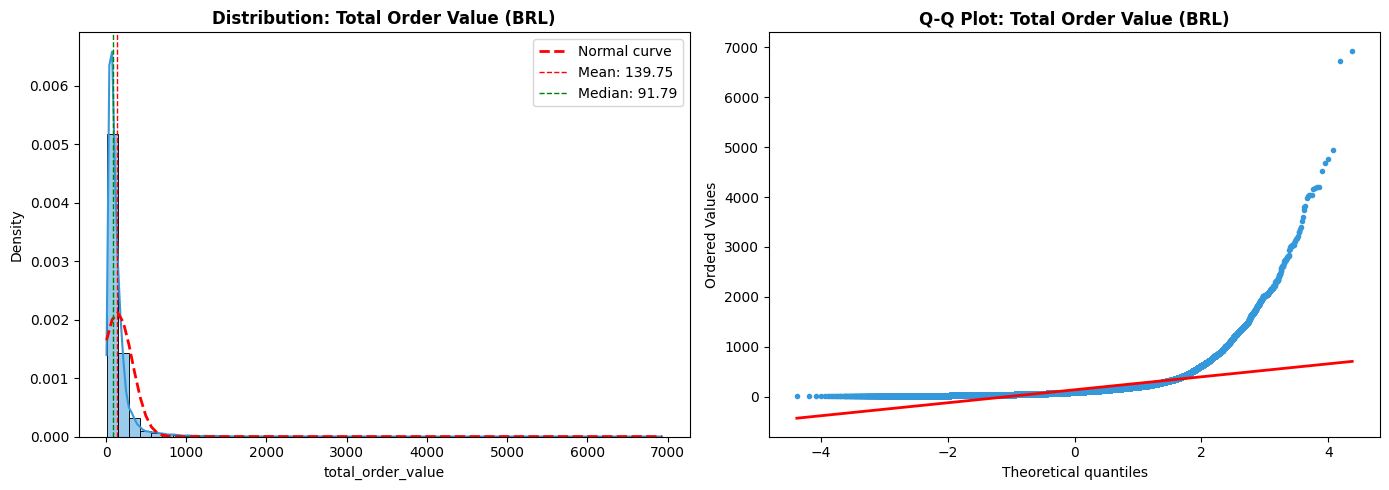

In [15]:
# ── 2. Visualize the distribution ────────────────────────────
plot_distribution(df_delivered, 'total_order_value', 
                  'Total Order Value (BRL)')

In [16]:
# ── 3. Normality test ─────────────────────────────────────────
test_normality(df_delivered, 'total_order_value', 
               'Total Order Value (BRL)')

──── Normality Test: Total Order Value (BRL) ────
Test:        D'Agostino-Pearson
Statistic:   153824.1688
P-value:     0.0000
Result:      Not Normal ❌ (α=0.05)



(np.float64(153824.16882135664), np.float64(0.0))

In [17]:
# ── 4. Confidence interval ────────────────────────────────────
confidence_interval(df_delivered, 'total_order_value',
                    confidence=0.95,
                    label='Total Order Value (BRL)')

──── 95% Confidence Interval: Total Order Value (BRL) ────
Sample Mean:  139.75
CI:           (138.66, 140.84)
Interpretation: We are 95% confident the true
               population mean lies between 138.66 and 140.84



(np.float64(138.6565380867798), np.float64(140.83625065689682))

**Log Transform for Non-Normal Variable**

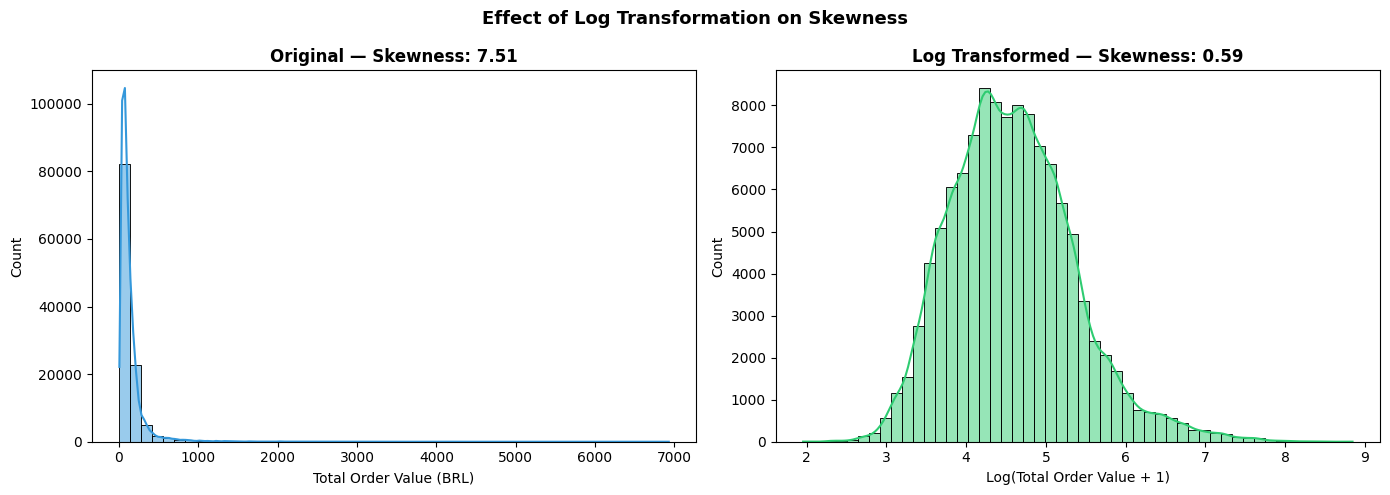

──── Descriptive Statistics: Log Transformed Order Value ────
     Metric    Value
0     Count  114,851
1      Mean     4.58
2    Median     4.53
3   Std Dev     0.78
4       Min     1.96
5  25th Pct     4.03
6  75th Pct     5.06
7       Max     8.84
8  Skewness    0.587
9  Kurtosis    0.748
──── Normality Test: Log Transformed Order Value ────
Test:        D'Agostino-Pearson
Statistic:   7157.2382
P-value:     0.0000
Result:      Not Normal ❌ (α=0.05)



(np.float64(7157.238228511393), np.float64(0.0))

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Log transform to reduce skewness
# np.log1p is log(x+1) — handles zeros safely
df_delivered['log_order_value'] = np.log1p(df_delivered['total_order_value'])

# Compare distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_delivered['total_order_value'], 
             bins=50, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Original — Skewness: 7.51', fontweight='bold')
axes[0].set_xlabel('Total Order Value (BRL)')

sns.histplot(df_delivered['log_order_value'],
             bins=50, kde=True, color='#2ecc71', ax=axes[1])
axes[1].set_title(f'Log Transformed — Skewness: {df_delivered["log_order_value"].skew():.2f}',
                  fontweight='bold')
axes[1].set_xlabel('Log(Total Order Value + 1)')

plt.suptitle('Effect of Log Transformation on Skewness',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(descriptive_summary(df_delivered, 'log_order_value',
                  'Log Transformed Order Value'))

# Test normality on log transformed data
test_normality(df_delivered, 'log_order_value',
               'Log Transformed Order Value')

In [19]:
# Demonstrate this — simulate perfectly normal data at different sample sizes
import scipy.stats as stats
import numpy as np

print('──── Normality test on PERFECTLY normal data ────\n')
for n in [100, 1000, 10000, 100000]:
    sample = np.random.normal(0, 1, n)  # truly normal data
    _, p   = stats.normaltest(sample)
    result = '✅ Normal' if p > 0.05 else '❌ Fails normality'
    print(f'n={n:>8,}:  p={p:.4f}  →  {result}')

──── Normality test on PERFECTLY normal data ────

n=     100:  p=0.3532  →  ✅ Normal
n=   1,000:  p=0.5062  →  ✅ Normal
n=  10,000:  p=0.0636  →  ✅ Normal
n= 100,000:  p=0.9425  →  ✅ Normal


## 📊 Note on Normality Testing at Scale

With n=114,859 the D'Agostino-Pearson test rejects normality even on
perfectly simulated normal data — demonstrating the large sample problem
where statistical significance diverges from practical significance.

**Decision:** Rely on visual inspection (histogram + Q-Q plot) and
skewness/kurtosis rather than p-value alone. With n > 5,000, the
Central Limit Theorem ensures parametric tests remain valid regardless
of the underlying distribution shape.

Log transformed order value (skewness=0.587, kurtosis within range)
is sufficiently normal for parametric testing purposes.

In [20]:
# Step 1 — Visual inspection (most important at large n)
test_normality(df_delivered, 'log_order_value', 'Log Order Value')

# Step 2 — Check skewness and kurtosis numerically
s = df_delivered['log_order_value']
print(f'Skewness: {s.skew():.3f}   (acceptable range: -1 to 1)')
print(f'Kurtosis: {s.kurtosis():.3f} (acceptable range: -2 to 2)')

# Step 3 — Central Limit Theorem safety net
print(f'\nSample size: {len(s):,}')
print('With n > 30, CLT applies — parametric tests are robust')
print('to non-normality regardless of distribution shape')



──── Normality Test: Log Order Value ────
Test:        D'Agostino-Pearson
Statistic:   7157.2382
P-value:     0.0000
Result:      Not Normal ❌ (α=0.05)

Skewness: 0.587   (acceptable range: -1 to 1)
Kurtosis: 0.748 (acceptable range: -2 to 2)

Sample size: 114,851
With n > 30, CLT applies — parametric tests are robust
to non-normality regardless of distribution shape


'''

> 💡 **Central Limit Theorem** — with large enough samples (n > 30), the sampling distribution of the mean approaches normality regardless of the underlying distribution. This is why parametric tests are still valid on our dataset despite failing the normality test.

---

## Practical Decision Rule

n < 30    → normality test result matters a lot
            use non-parametric if test fails

30 < n < 5000  → check visually + skewness/kurtosis
                 parametric generally safe if skewness < 1

n > 5000  → ignore normality test p-value entirely
            use visual inspection + skewness/kurtosis
            CLT makes parametric tests valid anyway
            consider non-parametric for ordinal data (review scores)
'''

**Test 1: Do high value orders take longer to deliver**

In [21]:
# ── Hypothesis ────────────────────────────────────────────────
# H0: Mean delivery days are equal for high and low value orders
# H1: High value orders take significantly longer to deliver

# Split into high/low value orders at median
median_value = df_delivered['total_order_value'].median()

low_value  = df_delivered[df_delivered['total_order_value'] <= median_value]['delivery_days']
high_value = df_delivered[df_delivered['total_order_value'] >  median_value]['delivery_days']

print(f'Median order value split point: BRL {median_value:.2f}')
print(f'Low value orders:  {len(low_value):,}')
print(f'High value orders: {len(high_value):,}')

Median order value split point: BRL 91.79
Low value orders:  57,431
High value orders: 57,420


In [22]:
# Check variance equality first — determines which t-test to use
from scipy import stats

#No need to do this as this check is already included in the two_sample_ttest function

# lev_stat, lev_p = stats.levene(low_value, high_value)
# print(f'Levene test p-value: {lev_p:.4f}')
# print(f'Equal variances: {lev_p > 0.05}')
# print()

# Run t-test 
stat, p = two_sample_ttest(
    low_value, high_value,
    label1='Low Value Orders',
    label2='High Value Orders'
)



──── Welch's t-test: Low Value Orders vs High Value Orders ────
Low Value Orders mean:  11.01
High Value Orders mean:  12.95
Difference:    -1.94
T-statistic:   -35.1784
P-value:       0.0000
Result:        Significant ✅ (α=0.05)



        delivery_days  order_type
0                 8.0   Low Value
1                 8.0   Low Value
2                 8.0   Low Value
5                13.0   Low Value
6                 2.0   Low Value
...               ...         ...
115405           11.0  High Value
115407           22.0  High Value
115408           24.0  High Value
115409           17.0  High Value
115410           17.0  High Value

[114851 rows x 2 columns]


C:\Users\Hanisha\AppData\Local\Temp\ipykernel_19992\2620330725.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='order_type', y='delivery_days',


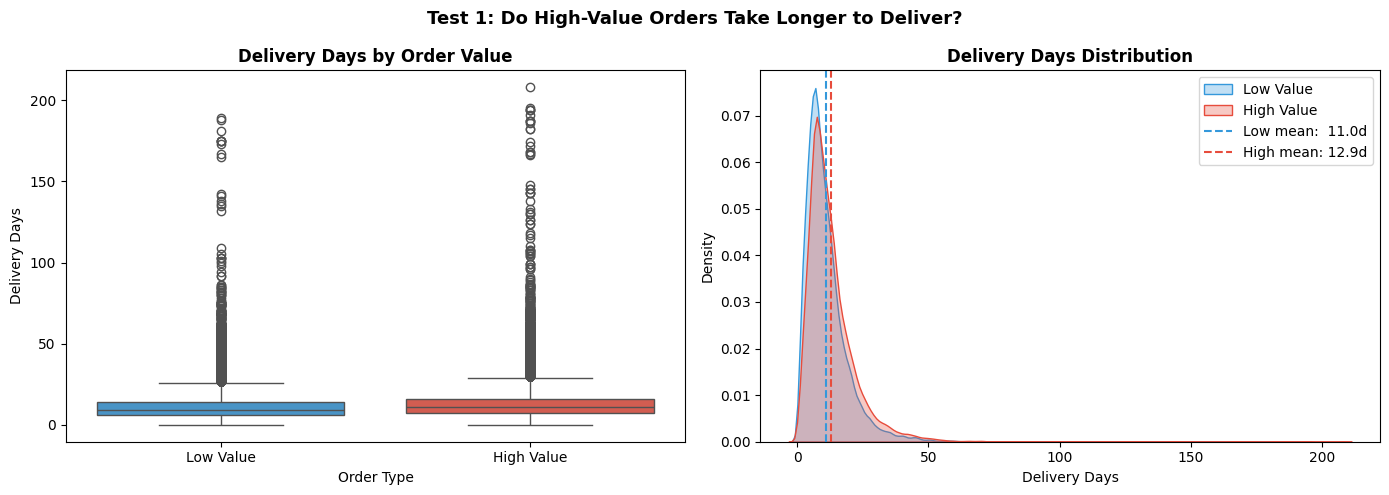

In [23]:
# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Box plot ────────────────────────────────────────────
plot_data = pd.DataFrame({
    'delivery_days': pd.concat([low_value, high_value]),
    'order_type':    ['Low Value'] * len(low_value) + ['High Value'] * len(high_value)
})

print(plot_data)


sns.boxplot(data=plot_data, x='order_type', y='delivery_days',
            palette=['#3498db', '#e74c3c'], ax=axes[0])
axes[0].set_title('Delivery Days by Order Value', fontweight='bold')
axes[0].set_xlabel('Order Type')
axes[0].set_ylabel('Delivery Days')

#KDE plot ~ Kernel Density Estimate to show distribution shape and overlap

# ── Right: KDE overlay ────────────────────────────────────────
sns.kdeplot(low_value,  ax=axes[1], label='Low Value',  color='#3498db', fill=True, alpha=0.3)
sns.kdeplot(high_value, ax=axes[1], label='High Value', color='#e74c3c', fill=True, alpha=0.3)
axes[1].axvline(low_value.mean(),  color='#3498db', linestyle='--', label=f'Low mean:  {low_value.mean():.1f}d')
axes[1].axvline(high_value.mean(), color='#e74c3c', linestyle='--', label=f'High mean: {high_value.mean():.1f}d')
axes[1].set_title('Delivery Days Distribution', fontweight='bold')
axes[1].set_xlabel('Delivery Days')
axes[1].legend()

plt.suptitle('Test 1: Do High-Value Orders Take Longer to Deliver?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



**Business implication:** High value orders consistently take ~2 days
longer to deliver. Possible causes include sourcing complexity, special
handling requirements, or fraud prevention checks. Recommend investigating
seller fulfillment times for high value SKUs specifically.

**Next steps:**
- Segment by product category to identify which categories drive the delay
- Compare seller fulfillment time vs carrier time separately

**Test 2: Does review score differ by payment type?**

In [24]:
# ── Hypothesis ────────────────────────────────────────────────
# H0: Review scores are equal across all payment types
# H1: At least one payment type has significantly different review scores

# Review scores are ordinal (1-5) — non-parametric test appropriate
print('──── Review Score Distribution ────')
print(df_delivered['review_score'].value_counts().sort_index())
print(f'\nPayment types: {df_delivered["payment_type"].unique()}')
print('\nMedian review score by payment type:')
print(df_delivered.groupby('payment_type')['review_score'].median())

──── Review Score Distribution ────
review_score
1    13114
2     3899
3     9649
4    22150
5    66039
Name: count, dtype: int64

Payment types: <StringArray>
['credit_card', 'voucher', 'boleto', 'debit_card']
Length: 4, dtype: str

Median review score by payment type:
payment_type
boleto         5.0
credit_card    5.0
debit_card     5.0
voucher        5.0
Name: review_score, dtype: float64


In [ ]:
# Extract groups
groups = []
labels = []

for payment in df_delivered['payment_type'].unique():
    group = df_delivered[df_delivered['payment_type'] == payment]['review_score']
    if len(group) > 30:   # only include groups with enough data
        groups.append(group)
        labels.append(payment)

# Review scores are ordinal (1-5), not continuous. Ordinal data
# violates ANOVA's normality assumption (3+ groups), Kruskal-Wallis tests
# rank distributions without assuming normality.

stat, p = kruskal_wallis_test(*groups, labels=labels)

──── Kruskal-Wallis Test ────
credit_card:
  n=84,725, median=5.00, mean=4.08
voucher:
  n=6,135, median=5.00, mean=4.06
boleto:
  n=22,337, median=5.00, mean=4.07
debit_card:
  n=1,654, median=5.00, mean=4.21

H-statistic: 19.5789
P-value:     0.0002
Result:      Significant difference ✅ (α=0.05)

──── Post-hoc: Pairwise Mann-Whitney (Bonferroni corrected) ────
  credit_card vs voucher: p=0.1676 ❌ (adjusted α=0.0083)
  credit_card vs boleto: p=0.1546 ❌ (adjusted α=0.0083)
  credit_card vs debit_card: p=0.0001 ✅ (adjusted α=0.0083)
  voucher vs boleto: p=0.5960 ❌ (adjusted α=0.0083)
  voucher vs debit_card: p=0.0000 ✅ (adjusted α=0.0083)
  boleto vs debit_card: p=0.0000 ✅ (adjusted α=0.0083)



C:\Users\Hanisha\AppData\Local\Temp\ipykernel_19992\442065143.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_delivered,


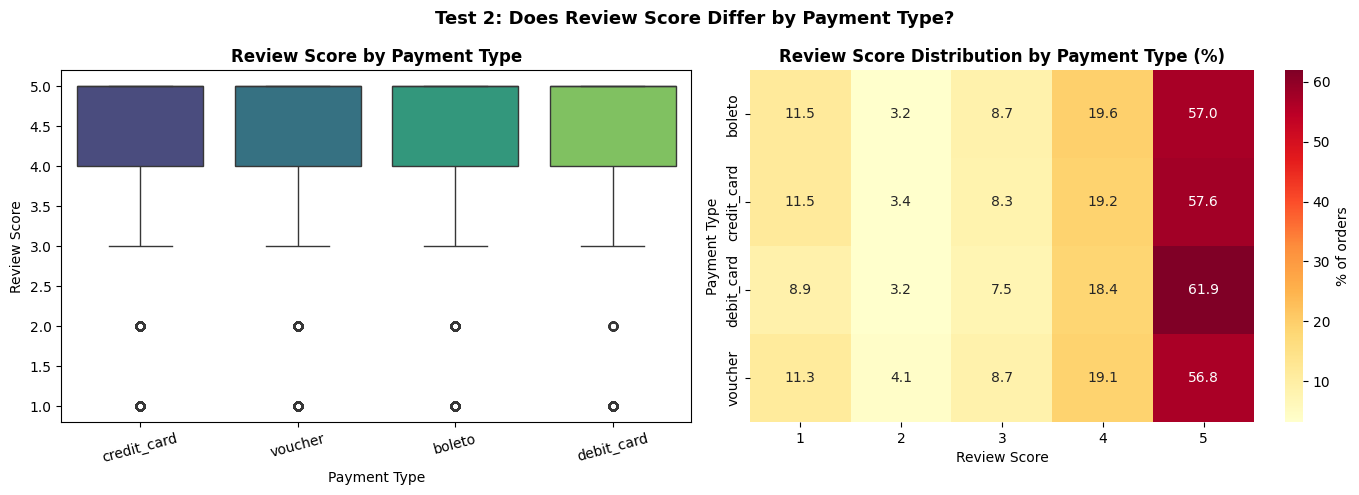

In [26]:
# Visualize review scores by payment type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Box plot ────────────────────────────────────────────
sns.boxplot(data=df_delivered,
            x='payment_type',
            y='review_score',
            palette='viridis',
            ax=axes[0])
axes[0].set_title('Review Score by Payment Type', fontweight='bold')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Review Score')
axes[0].tick_params(axis='x', rotation=15)

# ── Right: Heatmap of proportions ────────────────────────────
pivot = pd.crosstab(
    df_delivered['payment_type'],
    df_delivered['review_score'],
    normalize='index'
).round(3) * 100

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': '% of orders'})
axes[1].set_title('Review Score Distribution by Payment Type (%)',
                  fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Payment Type')

plt.suptitle('Test 2: Does Review Score Differ by Payment Type?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Test 2 Results: Review Score Differs by Payment Type ✅

**H0 rejected** — Kruskal-Wallis significant (p < 0.05)

- All payment types share median review score of 5
- However rank distributions differ significantly
- Post-hoc (Bonferroni corrected): debit card significantly
  differs from voucher, credit card and boleto


**Key insight:** Debit card users show a different review score
pattern and is worth investigating demographically.